In [ ]:
#DISHA NARENDRA THORAT
#PRN:3522511011
#ML MINI PROJECT

In [5]:
import os 
os.chdir(r"C:\Users\acer\Downloads\ml mini project")
os.getcwd()

'C:\\Users\\acer\\Downloads\\ml mini project'

In [ ]:
#Dataset: GSE114007 from NCBI Gene Expression Omnibus
#Organism: Homo sapiens
#Tissue: Human knee articular cartilage
#Technology: Bulk RNA sequencing
#Samples: 18 normal + 20 osteoarthritis
#Features: Gene-level RNA-seq expression/counts
#Task: Classification of OA vs normal cartilage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [6]:
raw = pd.read_excel(
    "GSE114007_raw_counts.xlsx",
    index_col=0
)

print("Raw data shape:", raw.shape)
raw.head()

Raw data shape: (23710, 18)


,Normal_Cart_10_8,Normal_Cart_2_2,Normal_Cart_3_3,Normal_Cart_4_4,Normal_Cart_5_5,Normal_Cart_6_6,Normal_Cart_7_3,Normal_Cart_9_7,normal_01,normal_02,normal_03,normal_04,normal_05,normal_06,normal_07,normal_08,normal_09,normal_10
symbol,,,,,,,,,,,,,,,,,,
A1BG,3,3,2,2,4,2,2,1,8,0,3,21,5,1,9,4,0,4
A1BG-AS1,1,3,0,1,0,2,2,0,0,3,1,8,2,3,2,0,1,1
A1CF,6,1,0,24,5,16,5,6,8,2,1,9,15,3,2,29,4,4
A2M,1780,1193,1073,8464,764,480,1457,2752,2275,681,3384,1913,1280,1887,3707,4667,3098,1540
A2M-AS1,61,36,25,360,50,45,54,65,75,12,51,38,36,43,17,82,59,30


In [7]:

excel = pd.ExcelFile("GSE114007_raw_counts.xlsx")

print(excel.sheet_names)

['Normal', 'OA']


In [8]:
for sheet in excel.sheet_names:
    temp = pd.read_excel(
        "GSE114007_raw_counts.xlsx",
        sheet_name=sheet,
        index_col=0
    )
    print(sheet, temp.shape)

Normal (23710, 18)
OA (23710, 20)


In [9]:
# Load the two sheets
normal = pd.read_excel(
    "GSE114007_raw_counts.xlsx",
    sheet_name="Normal",
    index_col=0
)

oa = pd.read_excel(
    "GSE114007_raw_counts.xlsx",
    sheet_name="OA",
    index_col=0
)

# Check shapes
print("Normal shape:", normal.shape)
print("OA shape:", oa.shape)

# Combine Healthy + OA samples
raw_counts = pd.concat([normal, oa], axis=1)

print("Combined raw counts shape:", raw_counts.shape)

# Show first few rows
raw_counts.head()

Normal shape: (23710, 18)
OA shape: (23710, 20)
Combined raw counts shape: (23710, 38)


,Normal_Cart_10_8,Normal_Cart_2_2,Normal_Cart_3_3,Normal_Cart_4_4,Normal_Cart_5_5,Normal_Cart_6_6,Normal_Cart_7_3,Normal_Cart_9_7,normal_01,normal_02,...,OA_01,OA_02,OA_03,OA_04,OA_05,OA_06,OA_07,OA_08,OA_09,OA_10
symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,3,3,2,2,4,2,2,1,8,0,...,4,11,2,4,3,1,4,3,5,10
A1BG-AS1,1,3,0,1,0,2,2,0,0,3,...,1,7,2,2,0,2,3,3,2,0
A1CF,6,1,0,24,5,16,5,6,8,2,...,12,14,10,16,9,14,10,14,10,17
A2M,1780,1193,1073,8464,764,480,1457,2752,2275,681,...,5514,5200,3587,8513,4106,5267,1202,8724,3677,2287
A2M-AS1,61,36,25,360,50,45,54,65,75,12,...,67,63,78,77,56,68,42,91,48,51


In [10]:
print("Number of genes:", raw_counts.shape[0])
print("Number of samples:", raw_counts.shape[1])

print("\nFirst 5 samples:")
print(raw_counts.columns[:5].tolist())

print("\nLast 5 samples:")
print(raw_counts.columns[-5:].tolist())

Number of genes: 23710
Number of samples: 38

First 5 samples:
['Normal_Cart_10_8', 'Normal_Cart_2_2', 'Normal_Cart_3_3', 'Normal_Cart_4_4', 'Normal_Cart_5_5']

Last 5 samples:
['OA_06', 'OA_07', 'OA_08', 'OA_09', 'OA_10']


In [11]:
print("Duplicate gene IDs:", raw_counts.index.duplicated().sum())

Duplicate gene IDs: 0


In [12]:
print("Missing values:", raw_counts.isna().sum().sum())

Missing values: 0


In [13]:
# Check how many genes have zero counts in each sample
zero_counts = (raw_counts == 0).sum(axis=1)

print("Zero-count summary:")
print(zero_counts.describe())

Zero-count summary:
count    23710.000000
mean         9.498018
std         13.266148
min          0.000000
25%          0.000000
50%          0.000000
75%         20.000000
max         38.000000
dtype: float64


In [14]:
# Keep genes expressed (>0) in at least 20% of samples
min_samples = int(raw_counts.shape[1] * 0.20)

keep_genes = (raw_counts > 0).sum(axis=1) >= min_samples

filtered_counts = raw_counts.loc[keep_genes]

print("Before filtering:", raw_counts.shape)
print("After filtering:", filtered_counts.shape)
print("Genes removed:", raw_counts.shape[0] - filtered_counts.shape[0])

Before filtering: (23710, 38)
After filtering: (20909, 38)
Genes removed: 2801


In [15]:
# Log2 transformation
log2_counts = np.log2(filtered_counts + 1)

print("Log2-transformed shape:", log2_counts.shape)

log2_counts.head()

Log2-transformed shape: (20909, 38)


,Normal_Cart_10_8,Normal_Cart_2_2,Normal_Cart_3_3,Normal_Cart_4_4,Normal_Cart_5_5,Normal_Cart_6_6,Normal_Cart_7_3,Normal_Cart_9_7,normal_01,normal_02,...,OA_01,OA_02,OA_03,OA_04,OA_05,OA_06,OA_07,OA_08,OA_09,OA_10
symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,2.000000,2.000000,1.584963,1.584963,2.321928,1.584963,1.584963,1.000000,3.169925,0.000000,...,2.321928,3.584963,1.584963,2.321928,2.000000,1.000000,2.321928,2.000000,2.584963,3.459432
A1BG-AS1,1.000000,2.000000,0.000000,1.000000,0.000000,1.584963,1.584963,0.000000,0.000000,2.000000,...,1.000000,3.000000,1.584963,1.584963,0.000000,1.584963,2.000000,2.000000,1.584963,0.000000
A1CF,2.807355,1.000000,0.000000,4.643856,2.584963,4.087463,2.584963,2.807355,3.169925,1.584963,...,3.700440,3.906891,3.459432,4.087463,3.321928,3.906891,3.459432,3.906891,3.459432,4.169925
A2M,10.798472,10.221587,10.068778,13.047294,9.579316,8.909893,10.509775,11.426789,11.152285,9.413628,...,12.429145,12.344573,11.808964,13.055621,12.003869,12.363040,10.232421,13.090939,11.844706,11.159871
A2M-AS1,5.954196,5.209453,4.700440,8.495855,5.672425,5.523562,5.781360,6.044394,6.247928,3.700440,...,6.087463,6.000000,6.303781,6.285402,5.832890,6.108524,5.426265,6.523562,5.614710,5.700440


In [16]:
# Compare numerical ranges
print("Raw counts:")
print("Min:", filtered_counts.min().min())
print("Max:", filtered_counts.max().max())

print("\nAfter Log2 transformation:")
print("Min:", log2_counts.min().min())
print("Max:", log2_counts.max().max())

Raw counts:
Min: 0
Max: 1379624

After Log2 transformation:
Min: 0.0
Max: 20.395844746356218


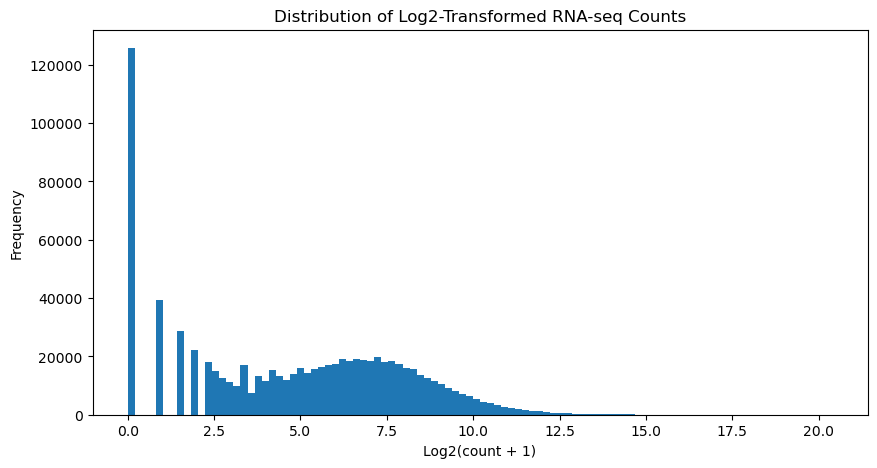

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(
    log2_counts.values.flatten(),
    bins=100
)

plt.xlabel("Log2(count + 1)")
plt.ylabel("Frequency")
plt.title("Distribution of Log2-Transformed RNA-seq Counts")

plt.show()

In [21]:

# Check for duplicate gene symbols
duplicate_genes = log2_counts.index.duplicated().sum()
print("Duplicate gene symbols:", duplicate_genes)

# Check dataset dimensions
print("\nDataset shape:", log2_counts.shape)
print("Number of genes:", log2_counts.shape[0])
print("Number of samples:", log2_counts.shape[1])

#  Check data type
print("\nData type:", log2_counts.dtypes.iloc[0])


Duplicate gene symbols: 0

Dataset shape: (20909, 38)
Number of genes: 20909
Number of samples: 38

Data type: float64


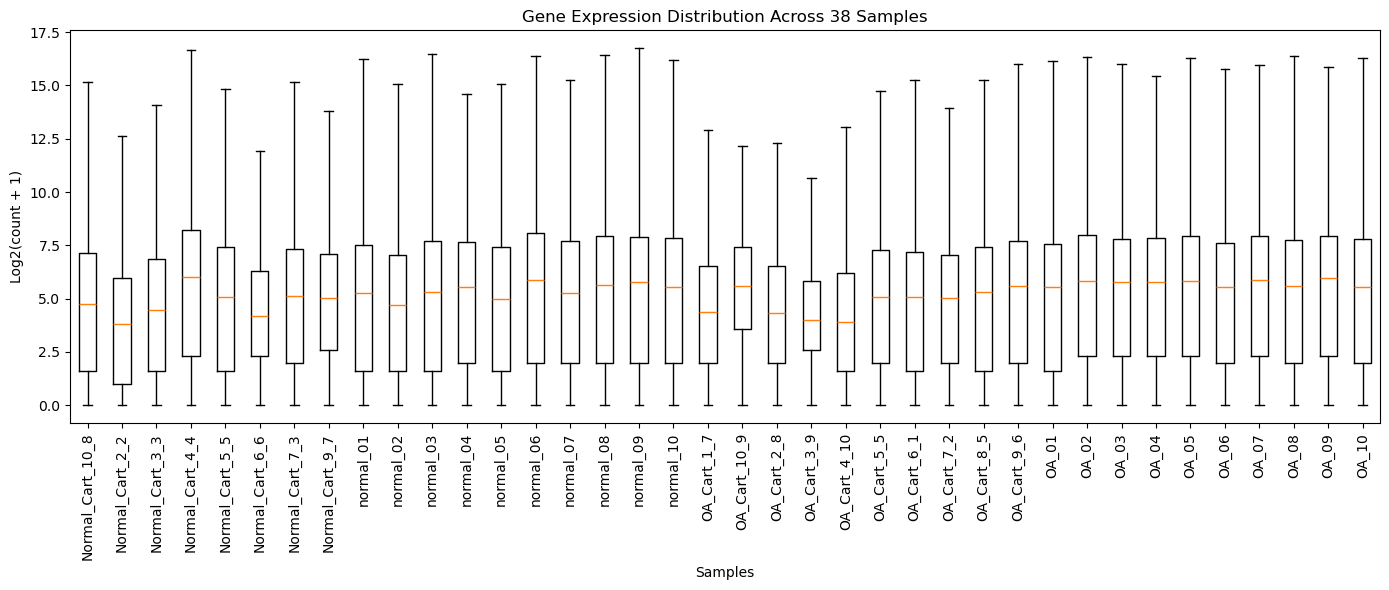

In [23]:
# Use 2,000 genes only for faster visualization
plot_data = log2_counts.sample(
    n=min(2000, log2_counts.shape[0]),
    random_state=42
)

plt.figure(figsize=(14, 6))

plt.boxplot(
    [plot_data[sample].values for sample in plot_data.columns],
    showfliers=False
)

plt.xlabel("Samples")
plt.ylabel("Log2(count + 1)")
plt.title("Gene Expression Distribution Across 38 Samples")

plt.xticks(
    range(1, len(plot_data.columns) + 1),
    plot_data.columns,
    rotation=90
)

plt.tight_layout()
plt.show()

In [24]:
# Standardize genes for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(log2_counts)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PC1 variance:", pca.explained_variance_ratio_[0] * 100)
print("PC2 variance:", pca.explained_variance_ratio_[1] * 100)
print("Total variance:", pca.explained_variance_ratio_.sum() * 100)

PC1 variance: 90.27068894831196
PC2 variance: 3.3010038826194035
Total variance: 93.57169283093135


In [27]:
# Transpose: samples × genes
X_samples = log2_counts.T

print("PCA input shape:", X_samples.shape)

# Standardize each gene across samples
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_samples)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA output shape:", X_pca.shape)
print("PC1 variance:", pca.explained_variance_ratio_[0] * 100)
print("PC2 variance:", pca.explained_variance_ratio_[1] * 100)
print("Total variance:", pca.explained_variance_ratio_.sum() * 100)

PCA input shape: (38, 20909)
PCA output shape: (38, 2)
PC1 variance: 34.56327619393523
PC2 variance: 11.579042634569886
Total variance: 46.14231882850512


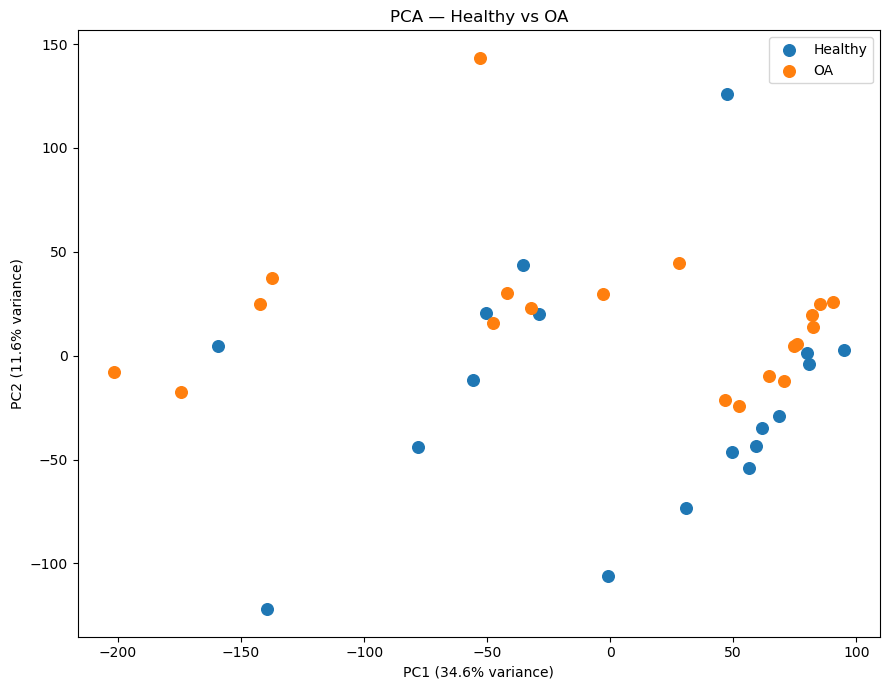

In [28]:

plt.figure(figsize=(9, 7))

for group, name in [(0, "Healthy"), (1, "OA")]:
    
    idx = labels["label"].values == group
    
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=name,
        s=70
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("PCA — Healthy vs OA")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
sample_type = pd.Series(
    ["Cart" if "Cart" in s else "Other" for s in X_samples.index],
    index=X_samples.index
)

print(sample_type.value_counts())

Other    20
Cart     18
Name: count, dtype: int64


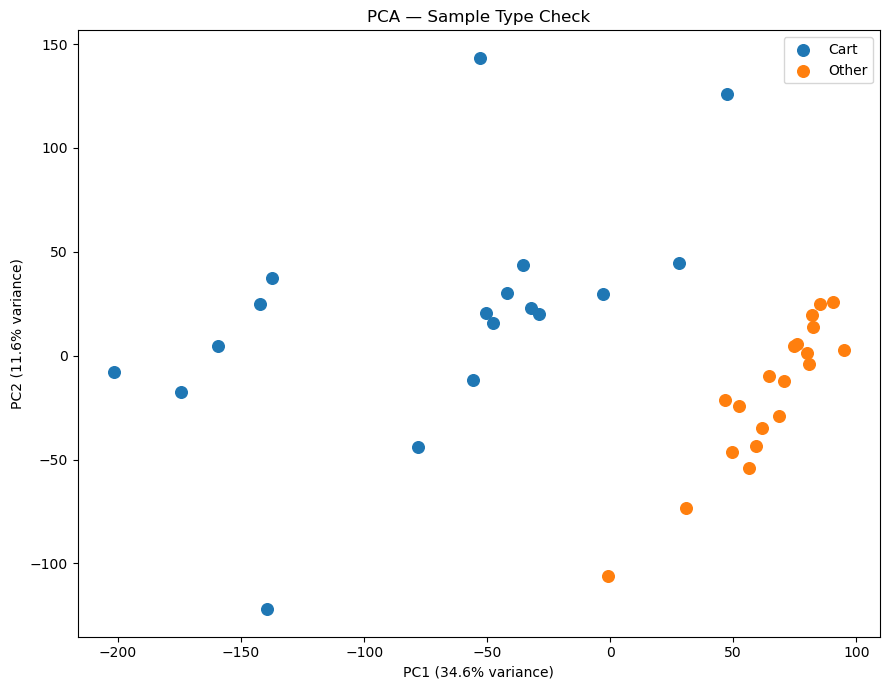

In [30]:
plt.figure(figsize=(9, 7))

for group in sample_type.unique():
    
    idx = sample_type.values == group
    
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=group,
        s=70
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("PCA — Sample Type Check")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Compare sample type with disease group

check = pd.crosstab(
    sample_type,
    labels["label"]
)

print(check)

label   0   1
row_0        
Cart    8  10
Other  10  10


In [32]:
print(
    pd.crosstab(
        sample_type,
        labels["label"],
        normalize="index"
    ).round(2)
)

label     0     1
row_0            
Cart   0.44  0.56
Other  0.50  0.50


In [33]:
print(log2_counts.columns.tolist())

['Normal_Cart_10_8', 'Normal_Cart_2_2', 'Normal_Cart_3_3', 'Normal_Cart_4_4', 'Normal_Cart_5_5', 'Normal_Cart_6_6', 'Normal_Cart_7_3', 'Normal_Cart_9_7', 'normal_01', 'normal_02', 'normal_03', 'normal_04', 'normal_05', 'normal_06', 'normal_07', 'normal_08', 'normal_09', 'normal_10', 'OA_Cart_1_7', 'OA_Cart_10_9', 'OA_Cart_2_8', 'OA_Cart_3_9', 'OA_Cart_4_10', 'OA_Cart_5_5', 'OA_Cart_6_1', 'OA_Cart_7_2', 'OA_Cart_8_5', 'OA_Cart_9_6', 'OA_01', 'OA_02', 'OA_03', 'OA_04', 'OA_05', 'OA_06', 'OA_07', 'OA_08', 'OA_09', 'OA_10']


In [34]:
# Platform annotation based on the GEO sample metadata
platform = []

for sample in log2_counts.columns:
    
    if "Cart" in sample:
        platform.append("GPL11154")
    else:
        platform.append("GPL18573")

platform = pd.Series(
    platform,
    index=log2_counts.columns,
    name="platform"
)

print(platform.value_counts())

platform
GPL18573    20
GPL11154    18
Name: count, dtype: int64


In [35]:
print(
    pd.crosstab(
        platform,
        labels["label"]
    )
)

label      0   1
platform        
GPL11154   8  10
GPL18573  10  10


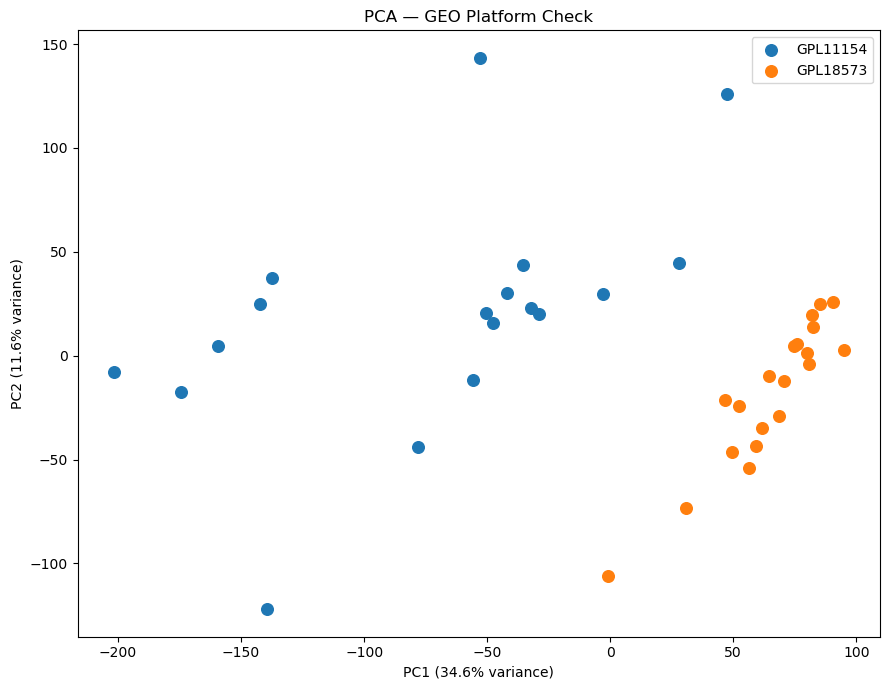

In [36]:
plt.figure(figsize=(9, 7))

for group in platform.unique():
    
    idx = platform.values == group
    
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=group,
        s=70
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA — GEO Platform Check")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
!pip install neuroCombat

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for neuroCombat: filename=neurocombat-0.2.12-py3-none-any.whl size=6409 sha256=45aa428f57f59e0b032872279178cf6d1b5d3161b3857cf5172715625768863c
  Stored in directory: c:\users\acer\appdata\local\pip\cache\wheels\74\73\fb\1290399bcdd875482fa7d3afc83ca375bf51118c97d309387b
Successfully built neuroCombat


In [39]:
# Disease labels
labels = pd.read_csv(r"C:\Users\acer\Downloads\ml mini project\labels (1).csv")
labels = labels.set_index("sample_id")

# Align labels to expression samples
labels = labels.loc[log2_counts.columns]

# Platform information
platform = pd.Series(
    ["GPL11154" if "Cart" in s else "GPL18573"
     for s in log2_counts.columns],
    index=log2_counts.columns,
    name="platform"
)

# Metadata for ComBat
covars = pd.DataFrame({
    "platform": platform,
    "label": labels["label"]
})

print(covars.head())
print(covars["platform"].value_counts())
print(covars["label"].value_counts())

                  platform  label
Normal_Cart_10_8  GPL11154      0
Normal_Cart_2_2   GPL11154      0
Normal_Cart_3_3   GPL11154      0
Normal_Cart_4_4   GPL11154      0
Normal_Cart_5_5   GPL11154      0
platform
GPL18573    20
GPL11154    18
Name: count, dtype: int64
label
1    20
0    18
Name: count, dtype: int64


In [40]:
from neuroCombat import neuroCombat

combat_result = neuroCombat(
    dat=log2_counts,
    covars=covars,
    batch_col="platform",
    categorical_cols=["label"]
)

combat_counts = pd.DataFrame(
    combat_result["data"],
    index=log2_counts.index,
    columns=log2_counts.columns
)

print("Corrected matrix shape:", combat_counts.shape)

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
Corrected matrix shape: (20909, 38)


In [41]:
combat_counts.to_csv("GSE114007_log2_ComBat_corrected.csv")

print("Saved: GSE114007_log2_ComBat_corrected.csv")

Saved: GSE114007_log2_ComBat_corrected.csv


In [42]:
# Samples × genes
X_corrected = combat_counts.T

# Scale genes
scaler_corrected = StandardScaler()
X_scaled_corrected = scaler_corrected.fit_transform(X_corrected)

# PCA
pca_corrected = PCA(n_components=2)
X_pca_corrected = pca_corrected.fit_transform(X_scaled_corrected)

print("PC1 variance:",
      pca_corrected.explained_variance_ratio_[0] * 100)

print("PC2 variance:",
      pca_corrected.explained_variance_ratio_[1] * 100)

PC1 variance: 25.017172880812932
PC2 variance: 12.383324409805784


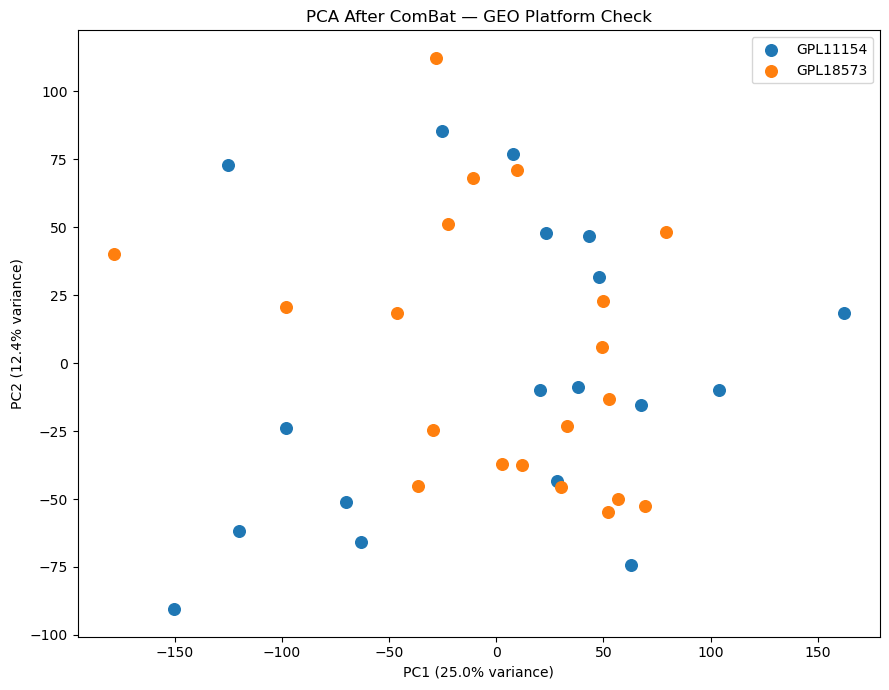

In [43]:

plt.figure(figsize=(9, 7))

for group in platform.unique():

    idx = platform.values == group

    plt.scatter(
        X_pca_corrected[idx, 0],
        X_pca_corrected[idx, 1],
        label=group,
        s=70
    )

plt.xlabel(
    f"PC1 ({pca_corrected.explained_variance_ratio_[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca_corrected.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("PCA After ComBat — GEO Platform Check")
plt.legend()
plt.tight_layout()
plt.show()

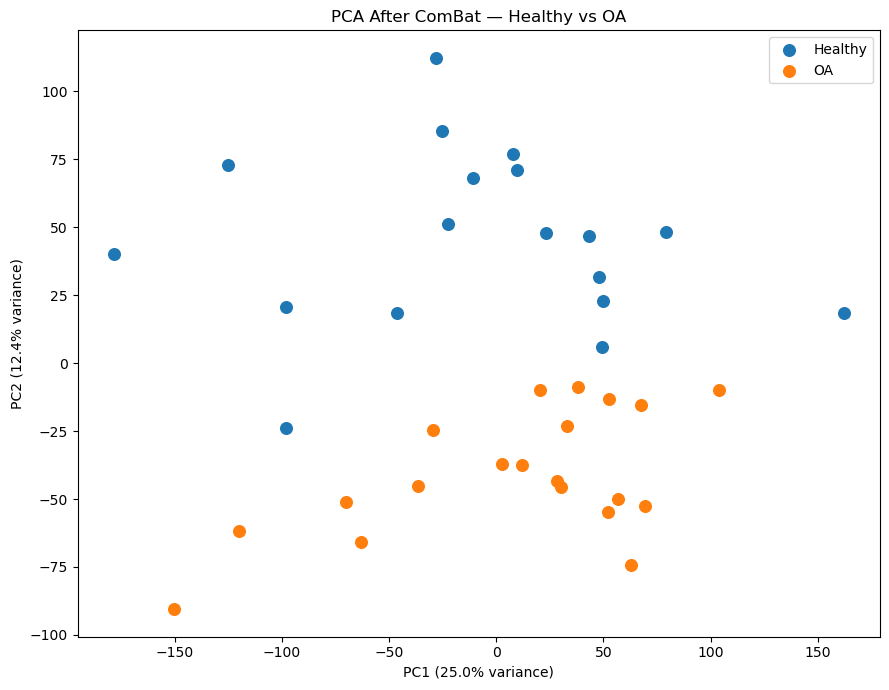

In [44]:
plt.figure(figsize=(9, 7))

for group, name in [(0, "Healthy"), (1, "OA")]:

    idx = labels["label"].values == group

    plt.scatter(
        X_pca_corrected[idx, 0],
        X_pca_corrected[idx, 1],
        label=name,
        s=70
    )

plt.xlabel(
    f"PC1 ({pca_corrected.explained_variance_ratio_[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca_corrected.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("PCA After ComBat — Healthy vs OA")
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
# Final expression matrix for ML
X = combat_counts.T

# Disease labels
y = labels["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

X shape: (38, 20909)
y shape: (38,)

Class distribution:
label
1    20
0    18
Name: count, dtype: int64


In [46]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Leakage-safe pipeline
logistic_pipeline = Pipeline([
    ("feature_selection", SelectKBest(
        score_func=f_classif,
        k=100
    )),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# Out-of-fold predictions
y_pred = cross_val_predict(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    method="predict"
)

# Out-of-fold probabilities
y_prob = cross_val_predict(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

print("Predictions generated successfully!")
print("Predictions:", y_pred)
print("Probabilities:", y_prob)

Predictions generated successfully!
Predictions: [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1]
Probabilities: [7.01637324e-04 2.45314107e-02 1.52160150e-03 1.39090034e-02
 3.41965290e-04 1.50031680e-01 2.81264184e-03 2.88137139e-03
 4.30452298e-02 5.96146574e-01 6.65047241e-04 1.85202137e-04
 1.79534351e-02 4.76372649e-03 1.09198420e-05 3.41132795e-03
 2.08071161e-02 2.23824602e-04 9.99016260e-01 9.84397834e-01
 9.86390206e-01 9.99888132e-01 9.96891824e-01 9.98317053e-01
 9.97754817e-01 9.80986694e-01 9.98352783e-01 9.70113371e-01
 9.99255649e-01 9.99219348e-01 9.89000192e-01 9.99184201e-01
 9.97734595e-01 9.94734168e-01 8.72279139e-01 9.99615027e-01
 9.98352796e-01 9.98669269e-01]


In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = roc_auc_score(y, y_prob)

tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

specificity = tn / (tn + fp)

print("Accuracy    :", round(accuracy, 3))
print("Precision   :", round(precision, 3))
print("Sensitivity :", round(recall, 3))
print("Specificity :", round(specificity, 3))
print("F1-score    :", round(f1, 3))
print("ROC-AUC     :", round(roc_auc, 3))

Accuracy    : 0.974
Precision   : 0.952
Sensitivity : 1.0
Specificity : 0.944
F1-score    : 0.976
ROC-AUC     : 1.0


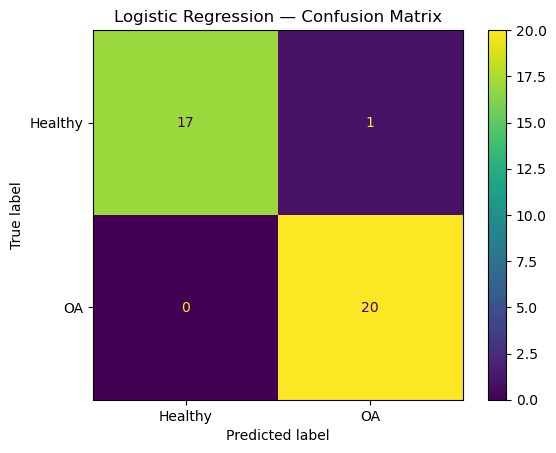

In [48]:

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred,
    display_labels=["Healthy", "OA"]
)

plt.title("Logistic Regression — Confusion Matrix")
plt.show()

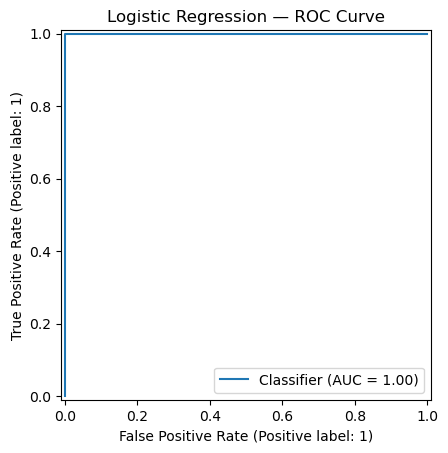

In [49]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y,
    y_prob
)

plt.title("Logistic Regression — ROC Curve")
plt.show()

In [52]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


In [51]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 2.5 MB/s eta 0:00:20
    --------------------------------------- 1.0/48.9 MB 2.5 MB/s eta 0:00:20
   - -------------------------------------- 1.8/48.9 MB 2.2 MB/s eta 0:00:22
   - -------------------------------------- 2.4/48.9 MB 2.3 MB/s eta 0:00:21
   -- ------------------------------------- 2.9/48.9 MB 2.4 MB/s eta 0:00:20
   -- ------------------------------------- 3.4/48.9 MB 2.4 MB/s eta 0:00:19
   --- ------------------------------------ 3.9/48.9 MB 2.4 MB/s eta 0:00:19
   --- ------------------------------------ 4.5/48.9 MB 2.4 MB/s eta 0:00:19
   --- -------------------

In [53]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

In [54]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []
predictions = {}
probabilities = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("feature_selection", SelectKBest(
            score_func=f_classif,
            k=100
        )),
        ("scaler", StandardScaler()),
        ("classifier", model)
    ])

    # Out-of-fold predictions
    y_pred = cross_val_predict(
        pipeline,
        X,
        y,
        cv=cv,
        method="predict"
    )

    # Out-of-fold probabilities
    y_prob = cross_val_predict(
        pipeline,
        X,
        y,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Sensitivity": recall_score(y, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, y_prob)
    })

    predictions[name] = y_pred
    probabilities[name] = y_prob

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC
0,Logistic Regression,0.973684,0.952381,1.00,0.944444,0.97561,1.000000
1,KNN,0.973684,0.952381,1.00,0.944444,0.97561,1.000000
2,SVM,1.000000,1.000000,1.00,1.000000,1.00000,1.000000
3,Naive Bayes,1.000000,1.000000,1.00,1.000000,1.00000,1.000000
4,Random Forest,0.973684,0.952381,1.00,0.944444,0.97561,1.000000
5,Extra Trees,0.973684,0.952381,1.00,0.944444,0.97561,1.000000
6,XGBoost,0.973684,0.952381,1.00,0.944444,0.97561,1.000000
7,Decision Tree,0.842105,0.850000,0.85,0.833333,0.85000,0.841667


In [55]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

robustness_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("feature_selection", SelectKBest(
            score_func=f_classif,
            k=100
        )),
        ("scaler", StandardScaler()),
        ("classifier", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=repeated_cv,
        scoring="roc_auc"
    )

    robustness_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "SD": scores.std(),
        "Min": scores.min(),
        "Max": scores.max()
    })

robustness_df = pd.DataFrame(robustness_results)

robustness_df = robustness_df.sort_values(
    "Mean ROC-AUC",
    ascending=False
).reset_index(drop=True)

robustness_df

,Model,Mean ROC-AUC,SD,Min,Max
0,Logistic Regression,1.000000,0.000000,1.000,1.0
1,KNN,1.000000,0.000000,1.000,1.0
2,SVM,1.000000,0.000000,1.000,1.0
3,Naive Bayes,1.000000,0.000000,1.000,1.0
4,Random Forest,1.000000,0.000000,1.000,1.0
5,Extra Trees,1.000000,0.000000,1.000,1.0
6,XGBoost,1.000000,0.000000,1.000,1.0
7,Decision Tree,0.939167,0.141718,0.375,1.0


In [56]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.base import clone

# Shuffle labels while keeping expression data unchanged
rng = np.random.RandomState(42)
y_shuffled = pd.Series(
    rng.permutation(y.values),
    index=y.index
)

permutation_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("feature_selection", SelectKBest(
            score_func=f_classif,
            k=100
        )),
        ("scaler", StandardScaler()),
        ("classifier", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y_shuffled,
        cv=repeated_cv,
        scoring="roc_auc"
    )

    permutation_results.append({
        "Model": name,
        "Shuffled Mean ROC-AUC": scores.mean(),
        "SD": scores.std()
    })

permutation_df = pd.DataFrame(permutation_results)

permutation_df

,Model,Shuffled Mean ROC-AUC,SD
0,Logistic Regression,0.435833,0.164033
1,KNN,0.386042,0.148289
2,SVM,0.393750,0.164531
3,Decision Tree,0.401667,0.135595
4,Naive Bayes,0.331042,0.140995
5,Random Forest,0.414583,0.156319
6,Extra Trees,0.353542,0.149426
7,XGBoost,0.397083,0.162040


In [57]:
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

# Select top 100 genes on the complete dataset
selector = SelectKBest(
    score_func=f_classif,
    k=100
)

X_selected = selector.fit_transform(X, y)

selected_genes = X.columns[selector.get_support()]

# Scale
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_selected_scaled, y)

print("XGBoost trained successfully.")
print("Number of selected genes:", len(selected_genes))

XGBoost trained successfully.
Number of selected genes: 100


In [60]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_selected_scaled)

print("SHAP matrix shape:", shap_values.shape)

SHAP matrix shape: (38, 100)


In [59]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ---------------

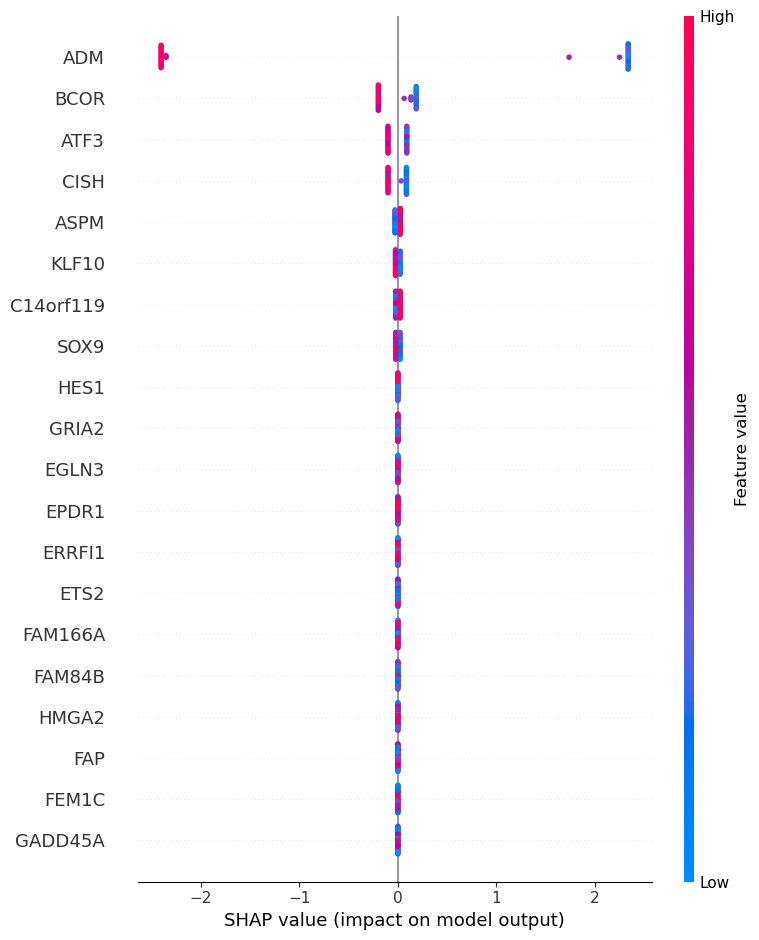

In [61]:
shap.summary_plot(
    shap_values,
    X_selected_scaled,
    feature_names=selected_genes,
    max_display=20
)

In [62]:
# Get mean absolute SHAP importance
shap_importance = pd.DataFrame({
    "Gene": selected_genes,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

print(shap_importance.head(20))

         Gene  Mean_Abs_SHAP
0         ADM       2.345670
7        BCOR       0.184316
4        ATF3       0.095376
18       CISH       0.091466
3        ASPM       0.026828
55      KLF10       0.023794
12  C14orf119       0.022458
85       SOX9       0.022253
74   PPP1R15A       0.000000
73      POSTN       0.000000
66      NDRG1       0.000000
71       PIM2       0.000000
70    PHACTR3       0.000000
69     PFKFB3       0.000000
68       PELO       0.000000
67      NR1D1       0.000000
72       PIM3       0.000000
63      MTFP1       0.000000
65      MYO7A       0.000000
64       MXI1       0.000000


In [63]:
top_genes = shap_importance.head(10)["Gene"].tolist()

print("Top 10 predictive genes:")
for i, gene in enumerate(top_genes, 1):
    print(i, gene)

Top 10 predictive genes:
1 ADM
2 BCOR
3 ATF3
4 CISH
5 ASPM
6 KLF10
7 C14orf119
8 SOX9
9 PPP1R15A
10 POSTN


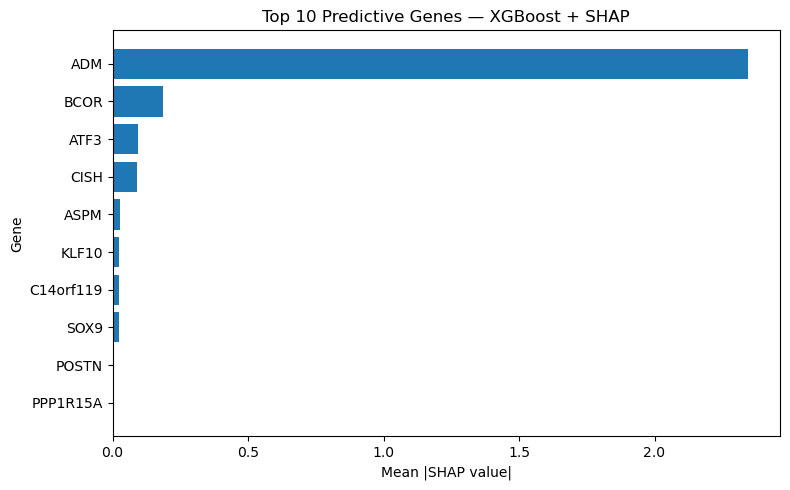

In [64]:
top10 = shap_importance.head(10).sort_values(
    "Mean_Abs_SHAP"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top10["Gene"],
    top10["Mean_Abs_SHAP"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Gene")
plt.title("Top 10 Predictive Genes — XGBoost + SHAP")

plt.tight_layout()
plt.show()

In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

tree_models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42
    )
}

tree_shap_values = {}
tree_importance = {}

for name, model in tree_models.items():

    # Train model
    model.fit(X_selected_scaled, y)

    # SHAP explainer
    explainer = shap.TreeExplainer(model)
    values = explainer.shap_values(X_selected_scaled)

    # Convert SHAP output to a 2D array: samples × genes
    if isinstance(values, list):
        values = values[-1]

    values = np.asarray(values)

    if values.ndim == 3:
        # binary classification: samples × genes × classes
        values = values[:, :, 1]

    elif values.ndim != 2:
        raise ValueError(
            f"Unexpected SHAP shape for {name}: {values.shape}"
        )

    tree_shap_values[name] = values

    # Mean absolute SHAP for every gene
    importance = pd.DataFrame({
        "Gene": selected_genes,
        "Mean_Abs_SHAP": np.abs(values).mean(axis=0)
    }).sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    ).reset_index(drop=True)

    tree_importance[name] = importance

    print(f"\n{name}")
    print("SHAP shape:", values.shape)
    print(importance.head(10))


Decision Tree
SHAP shape: (38, 100)
      Gene  Mean_Abs_SHAP
0     PIM2       0.498615
1      ADM       0.000000
2    MTFP1       0.000000
3    POSTN       0.000000
4     PIM3       0.000000
5  PHACTR3       0.000000
6   PFKFB3       0.000000
7     PELO       0.000000
8    NR1D1       0.000000
9    NDRG1       0.000000

Random Forest
SHAP shape: (38, 100)
     Gene  Mean_Abs_SHAP
0     HK2       0.027239
1   DDIT3       0.022655
2  ZNF395       0.021025
3    BCOR       0.018089
4   MYO7A       0.017572
5     CFI       0.015877
6   EPDR1       0.015365
7    MAFF       0.014963
8   SULF1       0.014903
9    RARA       0.012753

Extra Trees
SHAP shape: (38, 100)
        Gene  Mean_Abs_SHAP
0       MAFF       0.021286
1       CISH       0.020328
2  LOC143666       0.015677
3        ADM       0.015345
4       PIM2       0.014797
5       RARA       0.014211
6      DDIT3       0.013621
7     SLC2A1       0.012179
8     PFKFB3       0.011718
9       PELO       0.011441


In [67]:
from collections import Counter

top_gene_lists = {}

# XGBoost
top_gene_lists["XGBoost"] = (
    shap_importance.head(10)["Gene"].tolist()
)

# Other tree models
for name, importance in tree_importance.items():
    top_gene_lists[name] = importance.head(10)["Gene"].tolist()

for model_name, genes in top_gene_lists.items():
    print(f"\n{model_name}:")
    print(genes)


XGBoost:
['ADM', 'BCOR', 'ATF3', 'CISH', 'ASPM', 'KLF10', 'C14orf119', 'SOX9', 'PPP1R15A', 'POSTN']

Decision Tree:
['PIM2', 'ADM', 'MTFP1', 'POSTN', 'PIM3', 'PHACTR3', 'PFKFB3', 'PELO', 'NR1D1', 'NDRG1']

Random Forest:
['HK2', 'DDIT3', 'ZNF395', 'BCOR', 'MYO7A', 'CFI', 'EPDR1', 'MAFF', 'SULF1', 'RARA']

Extra Trees:
['MAFF', 'CISH', 'LOC143666', 'ADM', 'PIM2', 'RARA', 'DDIT3', 'SLC2A1', 'PFKFB3', 'PELO']


In [68]:
gene_counts = Counter()

for genes in top_gene_lists.values():
    gene_counts.update(genes)

cross_model_genes = pd.DataFrame(
    gene_counts.items(),
    columns=["Gene", "Number_of_Models"]
).sort_values(
    "Number_of_Models",
    ascending=False
).reset_index(drop=True)

print(cross_model_genes.head(20))

         Gene  Number_of_Models
0         ADM                 3
1       POSTN                 2
2        RARA                 2
3        MAFF                 2
4       DDIT3                 2
5        PELO                 2
6        BCOR                 2
7        PIM2                 2
8      PFKFB3                 2
9        CISH                 2
10   PPP1R15A                 1
11       SOX9                 1
12  LOC143666                 1
13       ATF3                 1
14      SULF1                 1
15      EPDR1                 1
16        CFI                 1
17      MYO7A                 1
18     ZNF395                 1
19       ASPM                 1


In [69]:
# Combine SHAP importance from all tree models

gene_summary = pd.DataFrame({
    "Gene": selected_genes
})

# XGBoost
xgb_imp = shap_importance.set_index("Gene")["Mean_Abs_SHAP"]
gene_summary["XGBoost_SHAP"] = gene_summary["Gene"].map(xgb_imp)

# Other tree models
for model_name, importance in tree_importance.items():
    imp = importance.set_index("Gene")["Mean_Abs_SHAP"]
    gene_summary[model_name.replace(" ", "_") + "_SHAP"] = (
        gene_summary["Gene"].map(imp)
    )

# Number of models in which each gene is top 10
gene_summary["Models_Top10"] = (
    gene_summary["Gene"]
    .map(gene_counts)
    .fillna(0)
    .astype(int)
)

# Sort primarily by cross-model consistency
gene_summary = gene_summary.sort_values(
    ["Models_Top10", "XGBoost_SHAP"],
    ascending=[False, False]
)

print(gene_summary.head(20))

         Gene  XGBoost_SHAP  Decision_Tree_SHAP  Random_Forest_SHAP  \
0         ADM      2.345670            0.000000            0.009954   
7        BCOR      0.184316            0.000000            0.018089   
18       CISH      0.091466            0.000000            0.011288   
22      DDIT3      0.000000            0.000000            0.022655   
59       MAFF      0.000000            0.000000            0.014963   
68       PELO      0.000000            0.000000            0.009829   
69     PFKFB3      0.000000            0.000000            0.011639   
71       PIM2      0.000000            0.498615            0.011579   
73      POSTN      0.000000            0.000000            0.009399   
77       RARA      0.000000            0.000000            0.012753   
4        ATF3      0.095376            0.000000            0.004649   
3        ASPM      0.026828            0.000000            0.001639   
55      KLF10      0.023794            0.000000            0.004857   
12  C1

In [70]:

consensus_genes = [
    "ADM", "BCOR", "CISH", "DDIT3", "MAFF",
    "PELO", "PFKFB3", "PIM2", "POSTN", "RARA"
]

# Check which genes are present
available_genes = [
    g for g in consensus_genes
    if g in combat_counts.index
]

print("Genes available:")
print(available_genes)

Genes available:
['ADM', 'BCOR', 'CISH', 'DDIT3', 'MAFF', 'PELO', 'PFKFB3', 'PIM2', 'POSTN', 'RARA']


C:\Users\acer\AppData\Local\Temp\ipykernel_1624\2549930317.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


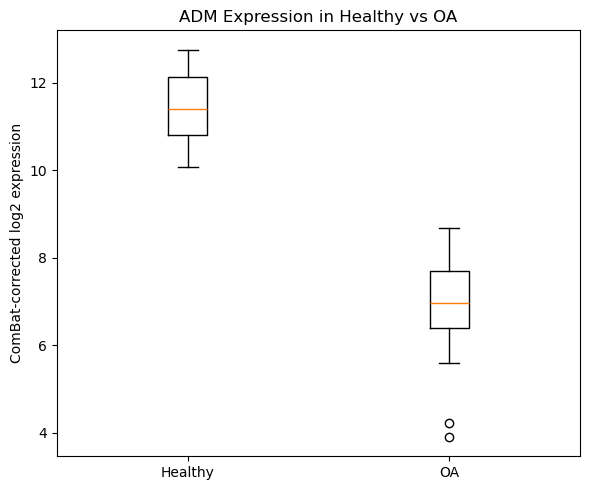

C:\Users\acer\AppData\Local\Temp\ipykernel_1624\2549930317.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


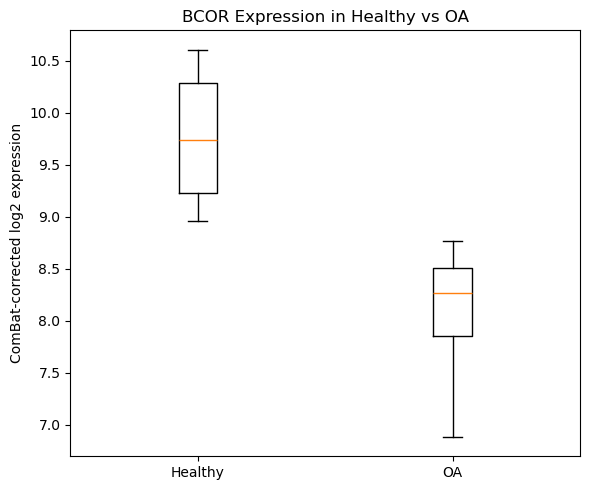

C:\Users\acer\AppData\Local\Temp\ipykernel_1624\2549930317.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


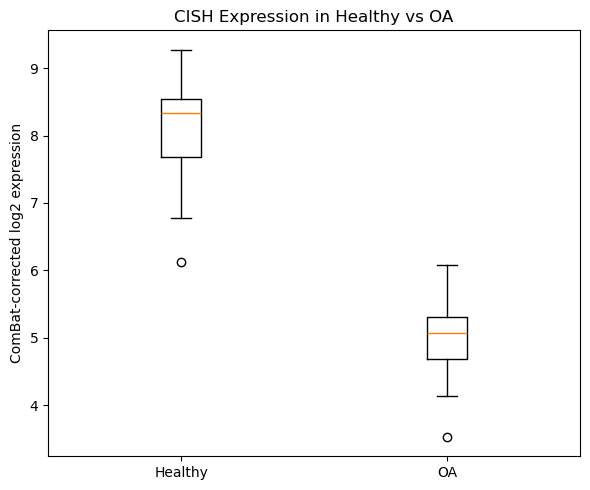

C:\Users\acer\AppData\Local\Temp\ipykernel_1624\2549930317.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


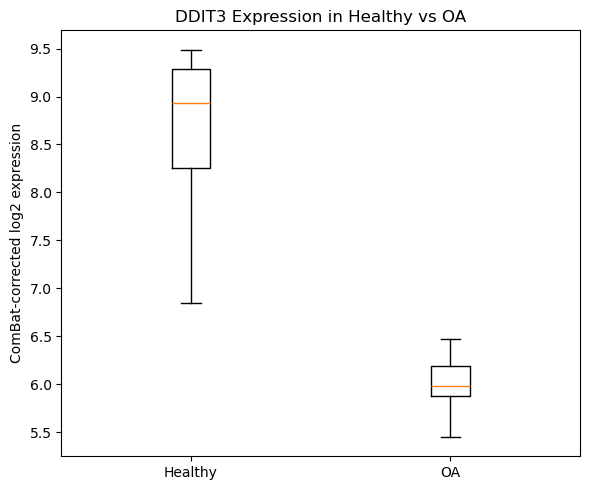

C:\Users\acer\AppData\Local\Temp\ipykernel_1624\2549930317.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


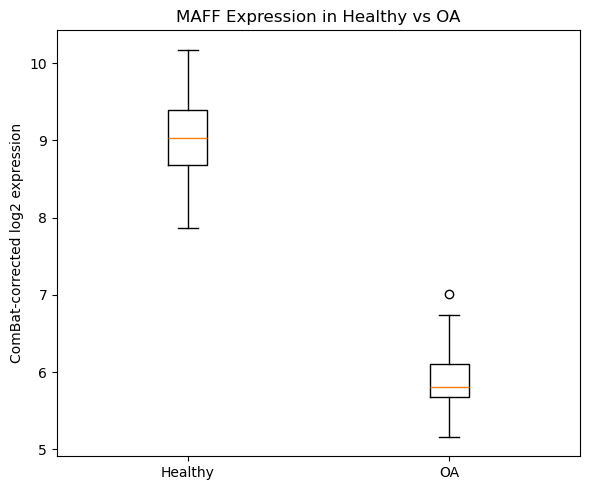

C:\Users\acer\AppData\Local\Temp\ipykernel_1624\2549930317.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


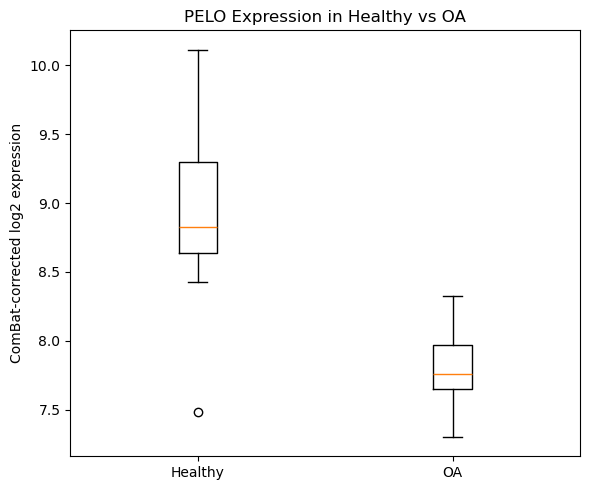

C:\Users\acer\AppData\Local\Temp\ipykernel_1624\2549930317.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


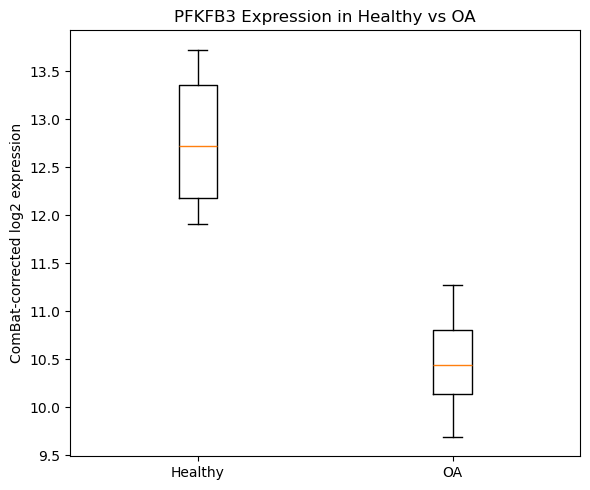

C:\Users\acer\AppData\Local\Temp\ipykernel_1624\2549930317.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


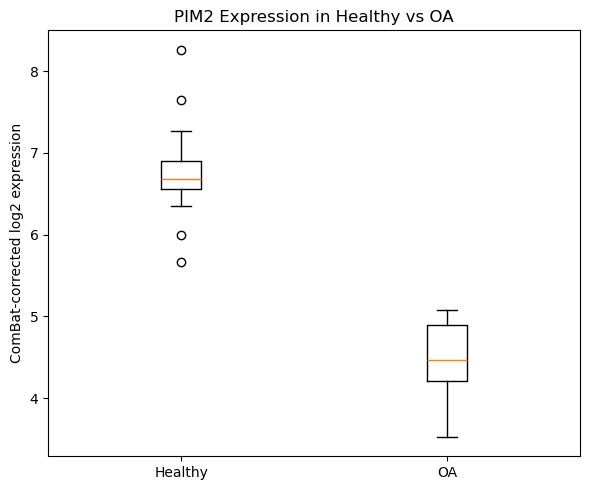

C:\Users\acer\AppData\Local\Temp\ipykernel_1624\2549930317.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


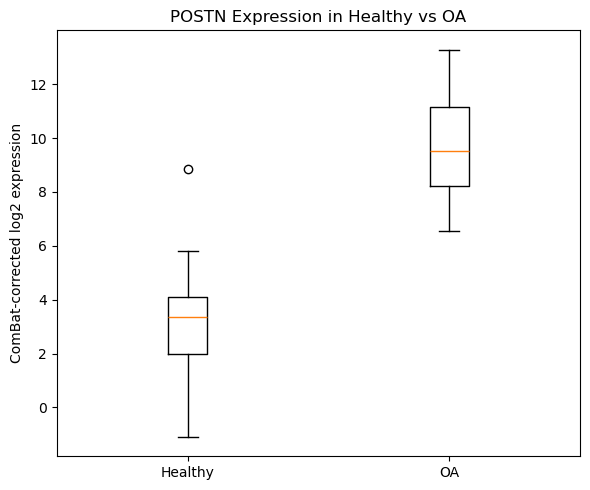

C:\Users\acer\AppData\Local\Temp\ipykernel_1624\2549930317.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


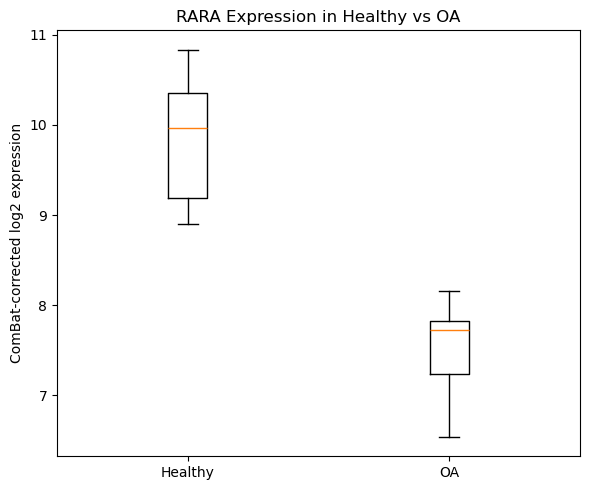

In [71]:
for gene in available_genes:

    healthy = combat_counts.loc[
        gene,
        labels["label"] == 0
    ]

    oa = combat_counts.loc[
        gene,
        labels["label"] == 1
    ]

    plt.figure(figsize=(6, 5))

    plt.boxplot(
        [healthy.values, oa.values],
        labels=["Healthy", "OA"]
    )

    plt.ylabel("ComBat-corrected log2 expression")
    plt.title(f"{gene} Expression in Healthy vs OA")

    plt.tight_layout()
    plt.show()

In [72]:
from scipy.stats import mannwhitneyu
import pandas as pd

summary = []

for gene in available_genes:

    healthy = combat_counts.loc[
        gene,
        labels["label"] == 0
    ]

    oa = combat_counts.loc[
        gene,
        labels["label"] == 1
    ]

    # Mann-Whitney U test
    stat, p = mannwhitneyu(
        healthy,
        oa,
        alternative="two-sided"
    )

    healthy_median = healthy.median()
    oa_median = oa.median()

    if oa_median > healthy_median:
        direction = "Higher in OA"
    else:
        direction = "Lower in OA"

    summary.append({
        "Gene": gene,
        "Healthy_median": healthy_median,
        "OA_median": oa_median,
        "Direction": direction,
        "P_value": p
    })

expression_stats = pd.DataFrame(summary)

# Multiple-testing correction
from statsmodels.stats.multitest import multipletests

expression_stats["Adjusted_P"] = multipletests(
    expression_stats["P_value"],
    method="fdr_bh"
)[1]

expression_stats = expression_stats.sort_values(
    "Adjusted_P"
)

expression_stats

,Gene,Healthy_median,OA_median,Direction,P_value,Adjusted_P
0,ADM,11.404700,6.955084,Lower in OA,1.539843e-07,1.924804e-07
1,BCOR,9.737298,8.270183,Lower in OA,1.539843e-07,1.924804e-07
2,CISH,8.334009,5.069233,Lower in OA,1.535052e-07,1.924804e-07
3,DDIT3,8.931518,5.983053,Lower in OA,1.532661e-07,1.924804e-07
4,MAFF,9.026920,5.807345,Lower in OA,1.535052e-07,1.924804e-07
6,PFKFB3,12.719544,10.435870,Lower in OA,1.539843e-07,1.924804e-07
7,PIM2,6.677968,4.464481,Lower in OA,1.508927e-07,1.924804e-07
9,RARA,9.970012,7.719630,Lower in OA,1.537446e-07,1.924804e-07
8,POSTN,3.374384,9.518352,Higher in OA,4.567690e-07,5.075211e-07
5,PELO,8.828220,7.763880,Lower in OA,1.753247e-06,1.753247e-06


In [73]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

healthy_idx = labels["label"].values == 0
oa_idx = labels["label"].values == 1

deg_results = []

for gene in combat_counts.index:

    healthy = combat_counts.loc[gene].values[healthy_idx]
    oa = combat_counts.loc[gene].values[oa_idx]

    stat, p = mannwhitneyu(
        healthy,
        oa,
        alternative="two-sided"
    )

    healthy_median = np.median(healthy)
    oa_median = np.median(oa)

    # median difference
    median_diff = oa_median - healthy_median

    deg_results.append([
        gene,
        healthy_median,
        oa_median,
        median_diff,
        p
    ])

deg_df = pd.DataFrame(
    deg_results,
    columns=[
        "Gene",
        "Healthy_Median",
        "OA_Median",
        "Median_Difference",
        "P_value"
    ]
)

# FDR correction
deg_df["Adjusted_P"] = multipletests(
    deg_df["P_value"],
    method="fdr_bh"
)[1]

# Sort by adjusted p-value
deg_df = deg_df.sort_values(
    "Adjusted_P"
).reset_index(drop=True)

print("Total genes tested:", len(deg_df))
deg_df.head(20)

Total genes tested: 20909


,Gene,Healthy_Median,OA_Median,Median_Difference,P_value,Adjusted_P
0,ELF3,6.383337,3.461157,-2.922181,6.173651e-07,0.000146
1,DDIT3,8.931518,5.983053,-2.948465,1.532661e-07,0.000146
2,LONRF3,6.670146,4.195690,-2.474456,5.327599e-07,0.000146
3,EFNA1,8.288647,6.369154,-1.919493,6.208593e-07,0.000146
4,TUBB3,1.519005,3.996432,2.477428,3.867341e-07,0.000146
5,ATF3,7.444730,3.727692,-3.717038,2.104886e-07,0.000146
6,EGLN3,9.253643,7.527636,-1.726006,3.368756e-07,0.000146
7,TTC9,3.739126,6.229728,2.490602,3.339054e-07,0.000146
8,STX11,6.093732,4.331676,-1.762056,4.574286e-07,0.000146
9,ASPM,1.520364,5.348008,3.827643,3.861689e-07,0.000146


In [74]:
significant_degs = deg_df[
    (deg_df["Adjusted_P"] < 0.05) &
    (abs(deg_df["Median_Difference"]) > 0.5)
]

print("Significant DEGs:", len(significant_degs))

significant_degs.head(20)

Significant DEGs: 4027


,Gene,Healthy_Median,OA_Median,Median_Difference,P_value,Adjusted_P
0,ELF3,6.383337,3.461157,-2.922181,6.173651e-07,0.000146
1,DDIT3,8.931518,5.983053,-2.948465,1.532661e-07,0.000146
2,LONRF3,6.670146,4.195690,-2.474456,5.327599e-07,0.000146
3,EFNA1,8.288647,6.369154,-1.919493,6.208593e-07,0.000146
4,TUBB3,1.519005,3.996432,2.477428,3.867341e-07,0.000146
5,ATF3,7.444730,3.727692,-3.717038,2.104886e-07,0.000146
6,EGLN3,9.253643,7.527636,-1.726006,3.368756e-07,0.000146
7,TTC9,3.739126,6.229728,2.490602,3.339054e-07,0.000146
8,STX11,6.093732,4.331676,-1.762056,4.574286e-07,0.000146
9,ASPM,1.520364,5.348008,3.827643,3.861689e-07,0.000146


In [75]:
# All significant DEGs
significant_genes = set(
    significant_degs["Gene"]
)

# Recurrent ML genes
ml_genes = set(
    consensus_genes
)

# Intersection
overlap_genes = sorted(
    significant_genes.intersection(ml_genes)
)

print("ML + DEG overlap:")
print(overlap_genes)

print("\nNumber of overlapping genes:", len(overlap_genes))

ML + DEG overlap:
['ADM', 'BCOR', 'CISH', 'DDIT3', 'MAFF', 'PELO', 'PFKFB3', 'PIM2', 'POSTN', 'RARA']

Number of overlapping genes: 10


In [76]:
final_gene_table = (
    expression_stats[
        expression_stats["Gene"].isin(overlap_genes)
    ]
    .merge(
        cross_model_genes,
        on="Gene",
        how="left"
    )
    .sort_values(
        ["Number_of_Models", "Adjusted_P"],
        ascending=[False, True]
    )
)

final_gene_table

,Gene,Healthy_median,OA_median,Direction,P_value,Adjusted_P,Number_of_Models
0,ADM,11.404700,6.955084,Lower in OA,1.539843e-07,1.924804e-07,3
1,BCOR,9.737298,8.270183,Lower in OA,1.539843e-07,1.924804e-07,2
2,CISH,8.334009,5.069233,Lower in OA,1.535052e-07,1.924804e-07,2
3,DDIT3,8.931518,5.983053,Lower in OA,1.532661e-07,1.924804e-07,2
4,MAFF,9.026920,5.807345,Lower in OA,1.535052e-07,1.924804e-07,2
5,PFKFB3,12.719544,10.435870,Lower in OA,1.539843e-07,1.924804e-07,2
6,PIM2,6.677968,4.464481,Lower in OA,1.508927e-07,1.924804e-07,2
7,RARA,9.970012,7.719630,Lower in OA,1.537446e-07,1.924804e-07,2
8,POSTN,3.374384,9.518352,Higher in OA,4.567690e-07,5.075211e-07,2
9,PELO,8.828220,7.763880,Lower in OA,1.753247e-06,1.753247e-06,2


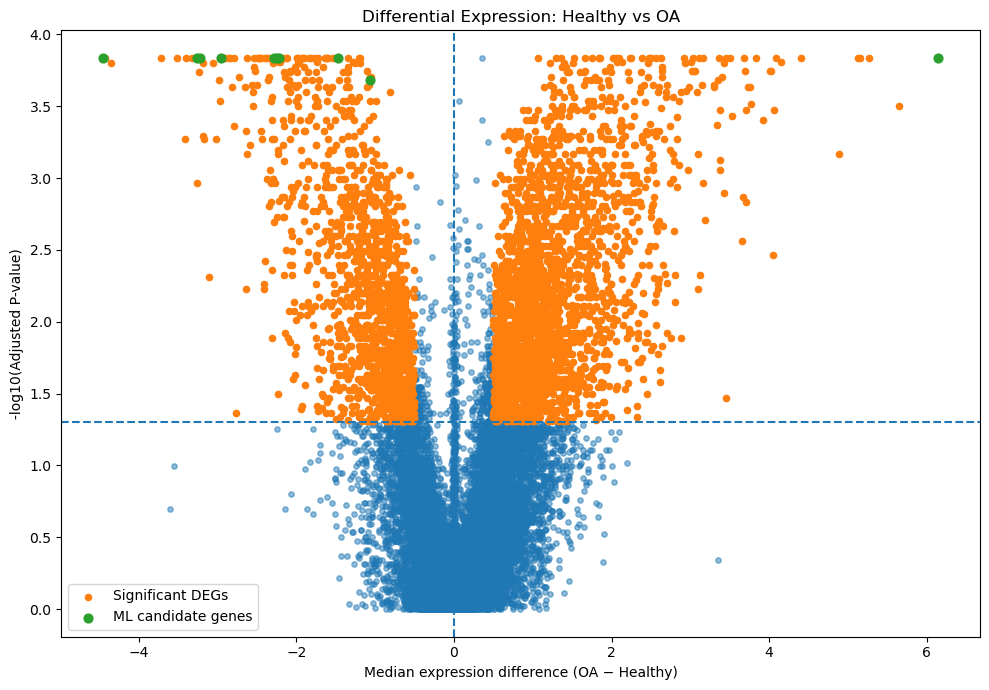

In [77]:
plt.figure(figsize=(10, 7))

x = deg_df["Median_Difference"]
y = -np.log10(deg_df["Adjusted_P"])

plt.scatter(
    x,
    y,
    alpha=0.5,
    s=15
)

# Significance threshold
sig = (
    (deg_df["Adjusted_P"] < 0.05) &
    (abs(deg_df["Median_Difference"]) > 0.5)
)

plt.scatter(
    x[sig],
    y[sig],
    s=20,
    label="Significant DEGs"
)

# Highlight ML genes
highlight = deg_df["Gene"].isin(consensus_genes)

plt.scatter(
    x[highlight],
    y[highlight],
    s=40,
    label="ML candidate genes"
)

plt.axhline(
    -np.log10(0.05),
    linestyle="--"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Median expression difference (OA − Healthy)")
plt.ylabel("-log10(Adjusted P-value)")
plt.title("Differential Expression: Healthy vs OA")
plt.legend()

plt.tight_layout()
plt.show()

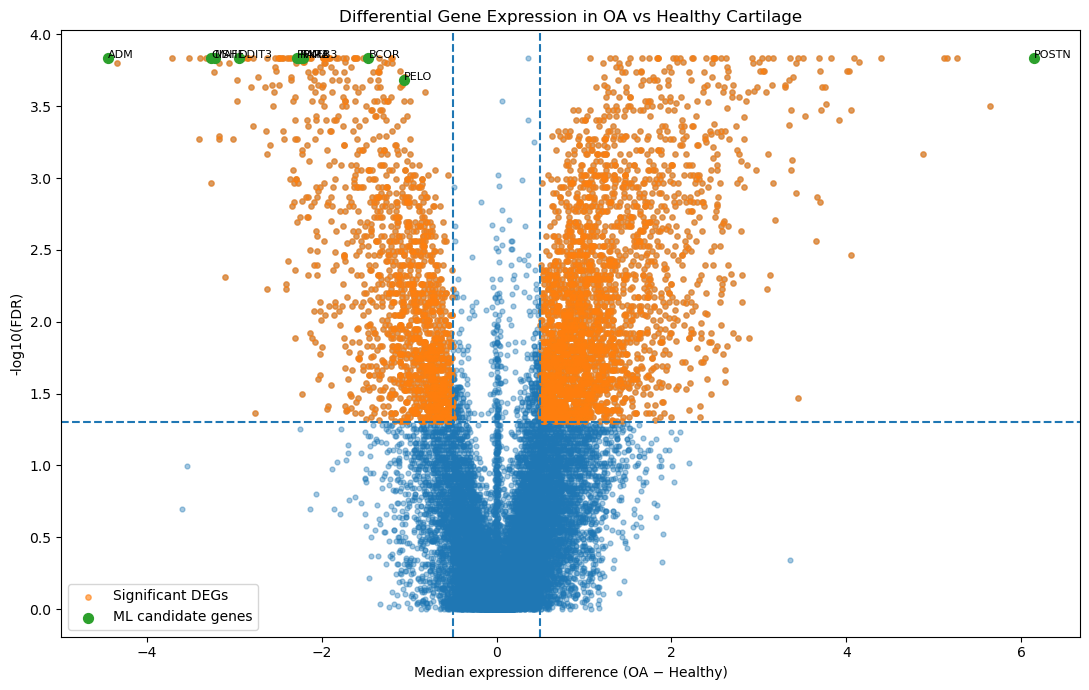

In [80]:

# Create -log10(FDR)
deg_df["neg_log10_FDR"] = -np.log10(
    deg_df["Adjusted_P"].clip(lower=1e-300)
)

# Significant DEGs
sig = (
    (deg_df["Adjusted_P"] < 0.05) &
    (abs(deg_df["Median_Difference"]) > 0.5)
)

# ML candidate genes
ml_highlight = deg_df["Gene"].isin(consensus_genes)

plt.figure(figsize=(11, 7))

# All genes
plt.scatter(
    deg_df["Median_Difference"],
    deg_df["neg_log10_FDR"],
    s=12,
    alpha=0.4
)

# Significant genes
plt.scatter(
    deg_df.loc[sig, "Median_Difference"],
    deg_df.loc[sig, "neg_log10_FDR"],
    s=15,
    alpha=0.6,
    label="Significant DEGs"
)

# ML candidate genes
plt.scatter(
    deg_df.loc[ml_highlight, "Median_Difference"],
    deg_df.loc[ml_highlight, "neg_log10_FDR"],
    s=50,
    label="ML candidate genes"
)

# Thresholds
plt.axhline(
    -np.log10(0.05),
    linestyle="--"
)

plt.axvline(
    -0.5,
    linestyle="--"
)

plt.axvline(
    0.5,
    linestyle="--"
)

# Label ML candidate genes
for _, row in deg_df[ml_highlight].iterrows():
    plt.annotate(
        row["Gene"],
        (row["Median_Difference"], row["neg_log10_FDR"]),
        fontsize=8
    )

plt.xlabel("Median expression difference (OA − Healthy)")
plt.ylabel("-log10(FDR)")
plt.title("Differential Gene Expression in OA vs Healthy Cartilage")
plt.legend()

plt.tight_layout()
plt.show()

In [81]:
# Final recurrent ML candidate genes
candidate_genes = [
    "ADM",
    "BCOR",
    "CISH",
    "DDIT3",
    "MAFF",
    "PFKFB3",
    "PIM2",
    "RARA",
    "POSTN",
    "PELO"
]

final_candidates = (
    expression_stats[
        expression_stats["Gene"].isin(candidate_genes)
    ]
    .merge(
        cross_model_genes[["Gene", "Number_of_Models"]],
        on="Gene",
        how="left"
    )
    .sort_values(
        ["Number_of_Models", "Adjusted_P"],
        ascending=[False, True]
    )
)

final_candidates

,Gene,Healthy_median,OA_median,Direction,P_value,Adjusted_P,Number_of_Models
0,ADM,11.404700,6.955084,Lower in OA,1.539843e-07,1.924804e-07,3
1,BCOR,9.737298,8.270183,Lower in OA,1.539843e-07,1.924804e-07,2
2,CISH,8.334009,5.069233,Lower in OA,1.535052e-07,1.924804e-07,2
3,DDIT3,8.931518,5.983053,Lower in OA,1.532661e-07,1.924804e-07,2
4,MAFF,9.026920,5.807345,Lower in OA,1.535052e-07,1.924804e-07,2
5,PFKFB3,12.719544,10.435870,Lower in OA,1.539843e-07,1.924804e-07,2
6,PIM2,6.677968,4.464481,Lower in OA,1.508927e-07,1.924804e-07,2
7,RARA,9.970012,7.719630,Lower in OA,1.537446e-07,1.924804e-07,2
8,POSTN,3.374384,9.518352,Higher in OA,4.567690e-07,5.075211e-07,2
9,PELO,8.828220,7.763880,Lower in OA,1.753247e-06,1.753247e-06,2


In [82]:
candidate_deg_overlap = deg_df[
    deg_df["Gene"].isin(candidate_genes)
].copy()

candidate_deg_overlap = candidate_deg_overlap.sort_values(
    "Adjusted_P"
)

candidate_deg_overlap[
    [
        "Gene",
        "Healthy_Median",
        "OA_Median",
        "Median_Difference",
        "P_value",
        "Adjusted_P"
    ]
]

,Gene,Healthy_Median,OA_Median,Median_Difference,P_value,Adjusted_P
1,DDIT3,8.931518,5.983053,-2.948465,1.532661e-07,0.000146
18,RARA,9.970012,7.719630,-2.250382,1.537446e-07,0.000146
21,POSTN,3.374384,9.518352,6.143968,4.567690e-07,0.000146
25,MAFF,9.026920,5.807345,-3.219575,1.535052e-07,0.000146
30,BCOR,9.737298,8.270183,-1.467114,1.539843e-07,0.000146
31,PFKFB3,12.719544,10.435870,-2.283675,1.539843e-07,0.000146
59,CISH,8.334009,5.069233,-3.264776,1.535052e-07,0.000146
60,ADM,11.404700,6.955084,-4.449616,1.539843e-07,0.000146
84,PIM2,6.677968,4.464481,-2.213487,1.508927e-07,0.000146
174,PELO,8.828220,7.763880,-1.064340,1.753247e-06,0.000208


In [83]:
print(
    "ML candidate genes found in whole-transcriptome DEG results:",
    candidate_deg_overlap.shape[0]
)

print(
    candidate_deg_overlap["Gene"].tolist()
)

ML candidate genes found in whole-transcriptome DEG results: 10
['DDIT3', 'RARA', 'POSTN', 'MAFF', 'BCOR', 'PFKFB3', 'CISH', 'ADM', 'PIM2', 'PELO']


In [84]:
significant_degs["Gene"]

0          ELF3
1         DDIT3
2        LONRF3
3         EFNA1
4         TUBB3
         ...   
4461      IFT88
4462       AFF2
4464      LRGUK
4465        EMB
4467    PYROXD2
Name: Gene, Length: 4027, dtype: object

In [85]:
# Get significant DEG symbols
enrichment_genes = significant_degs["Gene"].dropna().unique().tolist()

print("Number of genes for enrichment:", len(enrichment_genes))

# Save for enrichment tools
pd.DataFrame({
    "Gene": enrichment_genes
}).to_csv(
    "OA_significant_DEGs_for_enrichment.csv",
    index=False
)

print("Saved: OA_significant_DEGs_for_enrichment.csv")

Number of genes for enrichment: 4027
Saved: OA_significant_DEGs_for_enrichment.csv


In [86]:
print(enrichment_genes[:20])

['ELF3', 'DDIT3', 'LONRF3', 'EFNA1', 'TUBB3', 'ATF3', 'EGLN3', 'TTC9', 'STX11', 'ASPM', 'MPP2', 'SULF1', 'PREX2', 'RASSF7', 'ARNTL2', 'PDGFC', 'GDE1', 'BHLHE41', 'RARA', 'LOC143666']


In [87]:
import requests

url = "https://maayanlab.cloud/Enrichr/enrich"

response = requests.get(
    "https://maayanlab.cloud/Enrichr/"
)

print(response.status_code)

200


In [88]:
import requests

try:
    r = requests.get(
        "https://maayanlab.cloud/Enrichr/",
        timeout=10
    )
    print("Status:", r.status_code)
except Exception as e:
    print("Connection failed:", e)

Status: 200


In [90]:
for library in libraries:
    url = (
        "https://maayanlab.cloud/Enrichr/enrich"
        f"?userListId={user_list_id}"
        f"&backgroundType={library}"
    )

    r = requests.get(url, timeout=30)

    print(library, "status:", r.status_code)

    results = r.json()[library]

    df = pd.DataFrame(
        results,
        columns=[
            "Rank",
            "Term",
            "P_value",
            "Z_score",
            "Combined_score",
            "Genes",
            "Adjusted_P",
            "Old_P_value",
            "Old_Adjusted_P"
        ]
    )

    enrichment_results[library] = df

print("Enrichment completed!")

GO_Biological_Process_2023 status: 200
GO_Molecular_Function_2023 status: 200
GO_Cellular_Component_2023 status: 200
Enrichment completed!


In [91]:
bp = enrichment_results["GO_Biological_Process_2023"]
bp_sig = bp[bp["Adjusted_P"] < 0.05].sort_values("Adjusted_P")

bp_sig.head(20)

,Rank,Term,P_value,Z_score,Combined_score,Genes,Adjusted_P,Old_P_value,Old_Adjusted_P
0,1,Extracellular Matrix Organization (GO:0030198),0.000005,2.120937,26.085204,"[VIT, COL18A1, ECM2, ELN, PLOD3, LOXL1, ADAMTS...",0.017705,0,0
1,2,Extracellular Structure Organization (GO:0043062),0.000007,2.502114,29.629115,"[VIT, COL15A1, ECM2, COL13A1, COL11A1, NDNF, A...",0.017705,0,0
2,3,Regulation Of Vascular Associated Smooth Muscl...,0.000023,4.201943,44.849931,"[IL10, CDKN1A, DNMT1, JUN, CDKN1B, TGFB3, MMP2...",0.028750,0,0
3,4,External Encapsulating Structure Organization ...,0.000023,2.370849,25.281959,"[VIT, COL15A1, ECM2, COL13A1, COL11A1, NDNF, A...",0.028750,0,0
4,5,Liver Development (GO:0001889),0.000037,4.214165,43.008183,"[CEBPA, CEBPB, XBP1, CITED2, PHF1, CEBPG, PCSK...",0.036363,0,0


In [99]:
mf = enrichment_results["GO_Molecular_Function_2023"]
mf_sig = mf[mf["Adjusted_P"] < 0.05].sort_values("Adjusted_P")

cc = enrichment_results["GO_Cellular_Component_2023"]
cc_sig = cc[cc["Adjusted_P"] < 0.05].sort_values("Adjusted_P")

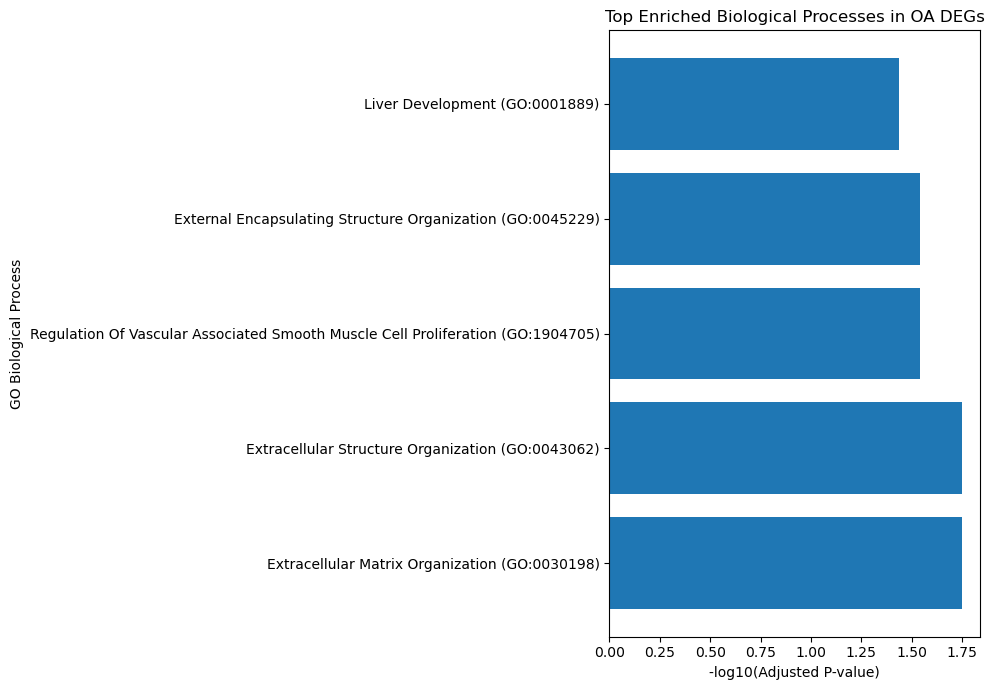

In [93]:
top_bp = bp_sig.head(10).copy()

top_bp = top_bp.sort_values("Adjusted_P", ascending=True)

top_bp["minus_log10_FDR"] = -np.log10(top_bp["Adjusted_P"])

plt.figure(figsize=(10, 7))

plt.barh(
    top_bp["Term"],
    top_bp["minus_log10_FDR"]
)

plt.xlabel("-log10(Adjusted P-value)")
plt.ylabel("GO Biological Process")
plt.title("Top Enriched Biological Processes in OA DEGs")

plt.tight_layout()
plt.show()

In [94]:
bp_sig.to_csv(
    "OA_GO_Biological_Process_enrichment.csv",
    index=False
)

In [100]:
mf_sig.head(10).to_string(index=False)

'Empty DataFrame\nColumns: [Rank, Term, P_value, Z_score, Combined_score, Genes, Adjusted_P, Old_P_value, Old_Adjusted_P]\nIndex: []'

In [96]:
cc_sig.head(10)

,Rank,Term,P_value,Z_score,Combined_score,Genes,Adjusted_P,Old_P_value,Old_Adjusted_P
0,1,Collagen-Containing Extracellular Matrix (GO:0...,1.151748e-08,1.932559,35.326018,"[VIT, SPARC, SERPINE2, TNC, F13A1, LOXL1, ICAM...",0.000005,0,0
1,2,Endoplasmic Reticulum Lumen (GO:0005788),4.034951e-08,2.050477,34.910781,"[COL18A1, POGLUT1, CSF1, FKBP14, SERPINA10, TN...",0.000008,0,0
2,3,Cyclin-Dependent Protein Kinase Holoenzyme Com...,2.354336e-05,3.981283,42.427203,"[CCNK, CDKN1A, CCNJ, CCNF, CCNB3, CCNA2, CCNB1...",0.003210,0,0
3,4,Intracellular Organelle Lumen (GO:0070013),3.160336e-04,1.331466,10.731166,"[SPARC, GMFG, NUDT1, TXNDC12, TXNDC16, TP53AIP...",0.032314,0,0


In [101]:
print("Total MF terms:", len(mf))
mf.head(10).to_string(index=False)

Total MF terms: 1012


' Rank                                                                             Term  P_value   Z_score  Combined_score                                                                                                                                                                                                                                                      Genes  Adjusted_P  Old_P_value  Old_Adjusted_P\n    1                                           Kinase Inhibitor Activity (GO:0019210) 0.000096  3.979052       36.807755                                                                                                                                 [CDKN1C, CDKN1A, NPM1, CDKN1B, GMFB, ITPRIP, YWHAB, GMFG, PRKRIP1, SPRY4, GSKIP, SOCS3, SOCS1, SH3BP5L, CDK1, TRIB1, NCK1]    0.096477            0               0\n    2                                   Protein Kinase Inhibitor Activity (GO:0004860) 0.000191  3.184028       27.271175                                                

In [102]:
mf.head(10).to_string(index=False)

' Rank                                                                             Term  P_value   Z_score  Combined_score                                                                                                                                                                                                                                                      Genes  Adjusted_P  Old_P_value  Old_Adjusted_P\n    1                                           Kinase Inhibitor Activity (GO:0019210) 0.000096  3.979052       36.807755                                                                                                                                 [CDKN1C, CDKN1A, NPM1, CDKN1B, GMFB, ITPRIP, YWHAB, GMFG, PRKRIP1, SPRY4, GSKIP, SOCS3, SOCS1, SH3BP5L, CDK1, TRIB1, NCK1]    0.096477            0               0\n    2                                   Protein Kinase Inhibitor Activity (GO:0004860) 0.000191  3.184028       27.271175                                                

In [103]:
cc_sig.head(10).to_string(index=False)

' Rank                                                            Term      P_value  Z_score  Combined_score                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    Genes  Adjusted_P  Old_P_value  Old_Adjusted_P\n    1           Collagen-Containing Extracellular Matrix (GO:0062023) 1.151748e-08 1.932559       35.326018 [VIT, SPARC,

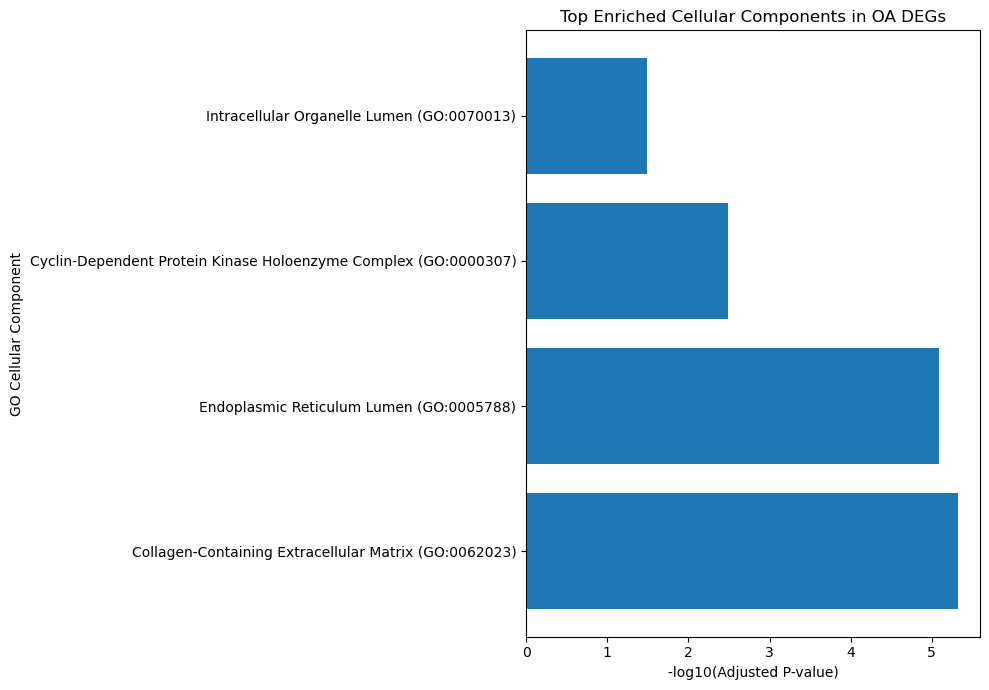

In [104]:
top_cc = cc_sig.head(10).copy()

top_cc = top_cc.sort_values("Adjusted_P", ascending=True)

top_cc["minus_log10_FDR"] = -np.log10(top_cc["Adjusted_P"])

plt.figure(figsize=(10, 7))

plt.barh(
    top_cc["Term"],
    top_cc["minus_log10_FDR"]
)

plt.xlabel("-log10(Adjusted P-value)")
plt.ylabel("GO Cellular Component")
plt.title("Top Enriched Cellular Components in OA DEGs")

plt.tight_layout()
plt.show()

In [105]:
cc_sig.to_csv(
    "OA_GO_Cellular_Component_enrichment.csv",
    index=False
)

In [107]:
final_candidates = pd.DataFrame({
    "Gene": [
        "ADM", "BCOR", "CISH", "DDIT3", "MAFF",
        "PFKFB3", "PIM2", "RARA", "POSTN", "PELO"
    ],
    "Healthy_median": [
        11.404700, 9.737298, 8.334009, 8.931518, 9.026920,
        12.719544, 6.677968, 9.970012, 3.374384, 8.828220
    ],
    "OA_median": [
        6.955084, 8.270183, 5.069233, 5.983053, 5.807345,
        10.435870, 4.464481, 7.719630, 9.518352, 7.763880
    ],
    "Direction": [
        "Lower in OA", "Lower in OA", "Lower in OA", "Lower in OA", "Lower in OA",
        "Lower in OA", "Lower in OA", "Lower in OA", "Higher in OA", "Lower in OA"
    ],
    "P_value": [
        1.539843e-07, 1.539843e-07, 1.535052e-07, 1.532661e-07,
        1.535052e-07, 1.539843e-07, 1.508927e-07, 1.537446e-07,
        4.567690e-07, 1.753247e-06
    ],
    "Adjusted_P": [
        1.924804e-07, 1.924804e-07, 1.924804e-07, 1.924804e-07,
        1.924804e-07, 1.924804e-07, 1.924804e-07, 1.924804e-07,
        5.075211e-07, 1.753247e-06
    ],
    "Models_Top10": [3, 2, 2, 2, 2, 2, 2, 2, 2, 2]
})

final_candidates

,Gene,Healthy_median,OA_median,Direction,P_value,Adjusted_P,Models_Top10
0,ADM,11.404700,6.955084,Lower in OA,1.539843e-07,1.924804e-07,3
1,BCOR,9.737298,8.270183,Lower in OA,1.539843e-07,1.924804e-07,2
2,CISH,8.334009,5.069233,Lower in OA,1.535052e-07,1.924804e-07,2
3,DDIT3,8.931518,5.983053,Lower in OA,1.532661e-07,1.924804e-07,2
4,MAFF,9.026920,5.807345,Lower in OA,1.535052e-07,1.924804e-07,2
5,PFKFB3,12.719544,10.435870,Lower in OA,1.539843e-07,1.924804e-07,2
6,PIM2,6.677968,4.464481,Lower in OA,1.508927e-07,1.924804e-07,2
7,RARA,9.970012,7.719630,Lower in OA,1.537446e-07,1.924804e-07,2
8,POSTN,3.374384,9.518352,Higher in OA,4.567690e-07,5.075211e-07,2
9,PELO,8.828220,7.763880,Lower in OA,1.753247e-06,1.753247e-06,2


In [108]:
final_candidates.to_csv(
    "OA_final_ML_candidate_genes.csv",
    index=False
)

print("Final candidate table saved!")

Final candidate table saved!


In [109]:
print("===== OA ML PROJECT: FINAL RESULTS =====\n")

print("Dataset:")
print(f"Samples: {X.shape[0]}")
print(f"Genes after filtering: {X.shape[1]}")
print("Healthy: 18")
print("OA: 20")

print("\nBest-performing models:")
print("SVM, Naive Bayes, Random Forest, Extra Trees, XGBoost")
print("Repeated 5-fold CV ROC-AUC ≈ 1.00")

print("\nTop recurrent ML/XAI genes:")
print(", ".join(final_candidates["Gene"]))

print("\nStrongest GO Biological Process:")
print("Extracellular Matrix Organization")

print("\nStrongest GO Cellular Component:")
print("Collagen-Containing Extracellular Matrix")

print("\nGO Molecular Function:")
print("No terms significant after FDR < 0.05")

===== OA ML PROJECT: FINAL RESULTS =====

Dataset:
Samples: 38
Genes after filtering: 20909
Healthy: 18
OA: 20

Best-performing models:
SVM, Naive Bayes, Random Forest, Extra Trees, XGBoost
Repeated 5-fold CV ROC-AUC ≈ 1.00

Top recurrent ML/XAI genes:
ADM, BCOR, CISH, DDIT3, MAFF, PFKFB3, PIM2, RARA, POSTN, PELO

Strongest GO Biological Process:
Extracellular Matrix Organization

Strongest GO Cellular Component:
Collagen-Containing Extracellular Matrix

GO Molecular Function:
No terms significant after FDR < 0.05


In [110]:
import os

print(os.listdir())

['GSE114007_log2_ComBat_corrected.csv', 'GSE114007_raw_counts.xlsx', 'labels (1).csv', 'OA_final_ML_candidate_genes.csv', 'OA_GO_Biological_Process_enrichment.csv', 'OA_GO_Cellular_Component_enrichment.csv', 'OA_significant_DEGs_for_enrichment.csv']


In [111]:
results_df

,Model,Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC
0,Logistic Regression,0.973684,0.952381,1.00,0.944444,0.97561,1.000000
1,KNN,0.973684,0.952381,1.00,0.944444,0.97561,1.000000
2,SVM,1.000000,1.000000,1.00,1.000000,1.00000,1.000000
3,Naive Bayes,1.000000,1.000000,1.00,1.000000,1.00000,1.000000
4,Random Forest,0.973684,0.952381,1.00,0.944444,0.97561,1.000000
5,Extra Trees,0.973684,0.952381,1.00,0.944444,0.97561,1.000000
6,XGBoost,0.973684,0.952381,1.00,0.944444,0.97561,1.000000
7,Decision Tree,0.842105,0.850000,0.85,0.833333,0.85000,0.841667


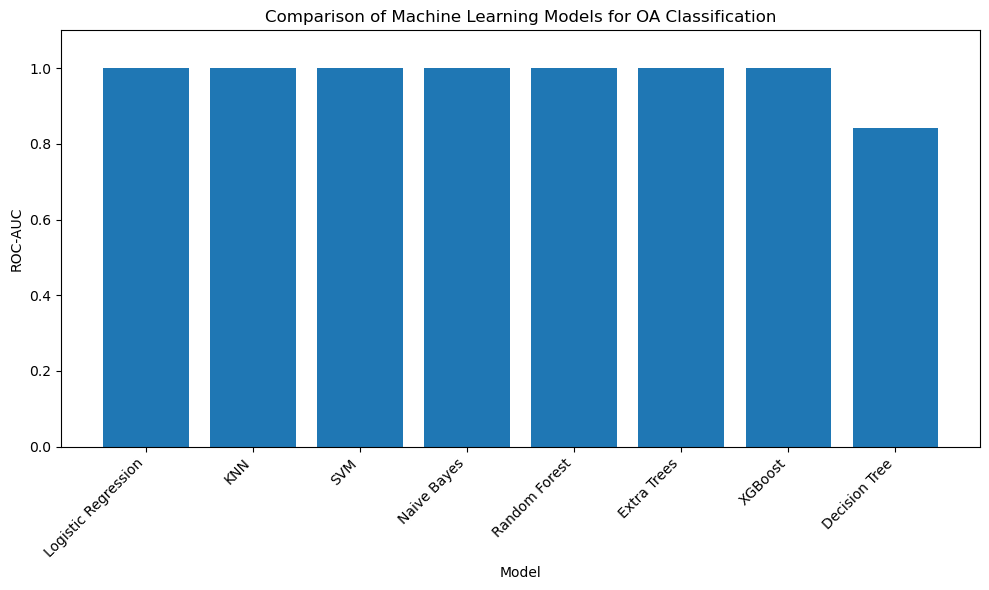

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(results_df["Model"], results_df["ROC-AUC"])

plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title("Comparison of Machine Learning Models for OA Classification")
plt.ylim(0, 1.1)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
## Results

After low-expression filtering and log2 transformation, 20,909 genes across 38 samples were retained for downstream analysis. PCA before batch correction showed variation associated with the two expression platforms, while ComBat correction improved mixing between platform groups.

Eight machine-learning classifiers were evaluated using stratified 5-fold cross-validation. SVM and Naive Bayes achieved 100% accuracy, sensitivity, specificity, F1-score, and ROC-AUC in the reported cross-validation analysis. Logistic Regression, KNN, Random Forest, Extra Trees, and XGBoost achieved 97.37% accuracy and ROC-AUC of 1.00. Decision Tree showed lower performance, with 84.21% accuracy and ROC-AUC of 0.842.

Repeated stratified 5-fold cross-validation showed ROC-AUC values of approximately 1.00 for seven models, whereas Decision Tree showed a lower mean ROC-AUC of approximately 0.939 ± 0.142.

SHAP analysis of tree-based models identified recurrent candidate genes across models. ADM appeared most frequently among the top-ranked features, while BCOR, CISH, DDIT3, MAFF, PELO, PFKFB3, PIM2, POSTN and RARA were also repeatedly identified.

Expression analysis of these recurrent candidates showed significant differences between healthy and OA samples after multiple-testing correction. POSTN showed higher expression in OA, whereas most of the other recurrent candidates showed lower expression in OA.

Exploratory differential-expression analysis identified significant transcriptomic differences between healthy and OA samples. GO enrichment analysis highlighted extracellular matrix-related biology, particularly extracellular matrix organization and extracellular structure organization. In the Cellular Component analysis, collagen-containing extracellular matrix was the strongest enriched term. No Molecular Function terms remained significant after FDR correction at the 0.05 threshold.

In [ ]:
## Conclusion

This study developed an exploratory and explainable machine-learning framework for distinguishing osteoarthritis from healthy knee cartilage using public gene-expression data.

The workflow integrated transcriptomic preprocessing, platform correction, dimensionality assessment, multiple machine-learning classifiers, cross-validation, SHAP-based feature interpretation, differential-expression analysis, and Gene Ontology enrichment.

Several machine-learning models showed strong classification performance, while SHAP analysis identified recurrent genes associated with model predictions. The biological interpretation of the identified genes was supported by enrichment of extracellular-matrix-related processes and collagen-containing extracellular matrix components.

Overall, the results demonstrate how machine learning and explainable AI can be combined with transcriptomic analysis to identify potentially informative molecular features associated with osteoarthritis.

In [ ]:
## Limitations

1. The study included only 38 samples, limiting statistical power and the generalizability of machine-learning performance estimates.

2. The analysis involved a high-dimensional gene-expression matrix with many more genes than samples.

3. ComBat batch correction was performed before cross-validation rather than being nested within each training fold. Therefore, the reported cross-validation performance may be optimistic.

4. The differential-expression analysis used an exploratory Mann–Whitney U test with FDR correction rather than a count-based RNA-seq differential-expression framework such as DESeq2.

5. SHAP-identified genes should be interpreted as model-associated candidate features rather than validated diagnostic biomarkers.

6. No independent external validation dataset was included in the final analysis.

7. Experimental validation would be required to determine whether the identified genes have functional or clinical relevance in osteoarthritis.

In [ ]:
## Future Work

Future work could include independent validation using additional osteoarthritis datasets, nested cross-validation with batch correction performed within each training fold, more rigorous RNA-seq differential-expression analysis, pathway-level analysis, and experimental validation of the most consistently identified candidate genes.